# Finding the Best Hyperparameters — Staff-Cut Classifier

In this notebook I tune several classification models on the IPEDS panel data and compare them fairly.

**The metric: PR-AUC** (area under the precision-recall curve). About 25% of institutions in the
training data actually cut staff, so a model that always predicts the majority class would score
PR-AUC = 0.25. That — not 0.5 — is the bar every model has to beat. (ROC-AUC's random line is 0.5,
which is why PR-AUC is the more honest metric here.)

**My approach:** start from a no-tuning baseline, then for each model pick its 1–2 hyperparameters
that actually matter, search them with a grid, zoom in around the winner, and finally compare all
models on identical folds so the comparison is fair.

## Cross-validation (random stratified k-fold)

Cross-validation (CV) means: split the training data into parts (folds), train on some parts,
score on the held-out part, rotate, and average — so the score reflects how the model does on
data it has never seen, without touching the final test set.

Here I use **10-fold stratified CV with shuffling** — the standard setup: each fold keeps the
same ~75/25 class ratio (stratified), and rows are assigned to folds randomly. Every model in
this notebook is tuned and compared on the exact same 10 folds, so the comparison is paired
and fair.

### How grid search works (Géron, 2022, *Hands-On Machine Learning*, ch. 2)

Grid search evaluates **every** hyperparameter combination in the grid with
cross-validation and keeps the one with the best mean score. Using the same 10 folds for
every candidate makes the comparisons paired and fair (Kuhn & Johnson, 2013, *Applied
Predictive Modeling*, ch. 4). The helper `grid_search(name, model, grid)` in the next
cell wraps this flow; `refit=True` retrains the winner on all of `X_train` automatically.

Grid search evaluates **every** hyperparameter combination in the grid with
cross-validation and keeps the one with the best mean score. Using the same 10 folds for
every candidate makes the comparisons paired and fair (Kuhn & Johnson, 2013, *Applied
Predictive Modeling*, ch. 4). After the search, `refit=True` automatically retrains the
winner on all of `X_train` — that *is* the "retrain with the best parameters" step
(Kuhn & Johnson, 2013, ch. 4.6), which is why no manual retraining appears anywhere below.
The helper `grid_search(name, model, grid)` in the next cell wraps exactly this flow.

**The candidate values are chosen before the search runs — grid search tries exactly
what it is given, nothing more.** Each grid below starts from the usual recommendations
for that model (mtry near √p for a forest, log-spaced C for the SVM; James et al., 2021;
Kuhn & Johnson, 2013) and is refined when the first pass comes back too coarse, as with
the SVM's coarse-to-fine sweep. Random search or Bayesian optimization would explore on
their own; here every tried value stays explicit and reproducible.

In [3]:
import warnings
from pandas.errors import PerformanceWarning
from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=PerformanceWarning)
warnings.filterwarnings('ignore', category=ConvergenceWarning)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import average_precision_score, confusion_matrix, ConfusionMatrixDisplay

DATA = '../Data/splits'
train = pd.read_csv(f'{DATA}/train_processed.csv')
valid = pd.read_csv(f'{DATA}/valid_processed.csv')
test  = pd.read_csv(f'{DATA}/test_processed.csv')
train['YEAR'] = pd.read_csv(f'{DATA}/train_raw.csv', usecols=['YEAR'])['YEAR'].values

X_train = train.drop(columns=['TARGET_STAFF_CUT', 'YEAR']); y_train = train['TARGET_STAFF_CUT']
years   = train['YEAR'].values
X_valid = valid.drop(columns=['TARGET_STAFF_CUT']); y_valid = valid['TARGET_STAFF_CUT']
X_test  = test.drop(columns=['TARGET_STAFF_CUT']);  y_test  = test['TARGET_STAFF_CUT']

from sklearn.model_selection import StratifiedKFold
CV = StratifiedKFold(n_splits=10, shuffle=True, random_state=1056)  # random stratified 10-fold
SCORING = 'average_precision'   # PR-AUC

def grid_search(name, model, grid):
    # STAGE 1 - SEARCH: train every candidate in `grid` on all 10 CV folds
    g = GridSearchCV(model, grid, cv=CV, scoring=SCORING, n_jobs=8, refit=True)
    g.fit(X_train, y_train)
    # STAGE 2 - PICK: the winner lives in these two attributes:
    #   g.best_params_  -> the winning hyperparameter combination
    #   g.best_score_   -> its mean PR-AUC across the 10 folds
    print(f'{name:12s} best CV PR-AUC = {g.best_score_:.3f} | {g.best_params_}')
    # STAGE 3 - REFIT (refit=True): the winner is retrained on ALL of X_train and
    # stored in g.best_estimator_ — that is the model used downstream.
    return g

def curve(g, param, logx=False, title=''):
    r = g.cv_results_
    x = np.array([p[param] for p in r['params']], dtype=float)
    o = np.argsort(x)
    plt.figure(figsize=(6, 3.2))
    plt.plot(x[o], r['mean_test_score'][o], 'o-')
    if logx: plt.xscale('log')
    plt.xlabel(param); plt.ylabel('CV PR-AUC'); plt.title(title); plt.grid(alpha=.3); plt.show()

print(f'train {X_train.shape} | valid {X_valid.shape} | test {X_test.shape}')
print(f'PR-AUC baselines: train {y_train.mean():.3f} | valid {y_valid.mean():.3f} | test {y_test.mean():.3f}')

train (5133, 238) | valid (768, 238) | test (778, 238)
PR-AUC baselines: train 0.253 | valid 0.237 | test 0.181


## 1. Logistic regression — the baseline (nothing to tune)

A plain logistic regression has no hyperparameters worth tuning, which makes it the perfect
baseline: every fancier model has to justify its complexity by beating this number.

In [4]:
lr = Pipeline([('sc', StandardScaler()), ('m', LogisticRegression(max_iter=3000, class_weight='balanced'))])
lr_scores = cross_val_score(lr, X_train, y_train, cv=CV, scoring=SCORING, n_jobs=4)
lr.fit(X_train, y_train)
print(f'baseline CV PR-AUC = {lr_scores.mean():.3f}  (per fold: {lr_scores.round(3)})')

# how the untuned baseline does on the untouched 2022 year, next to the no-skill floor
lr_test = average_precision_score(y_test, lr.predict_proba(X_test)[:, 1])
print(f'baseline TEST PR-AUC (2022) = {lr_test:.3f}  | no-skill floor (prevalence) = {y_test.mean():.3f}')

baseline CV PR-AUC = 0.458  (per fold: [0.465 0.469 0.459 0.456 0.441 0.475 0.525 0.407 0.404 0.476])
baseline TEST PR-AUC (2022) = 0.234  | no-skill floor (prevalence) = 0.181


## 2. Penalized logistic — tuning shrinkage strength and type

Regularized logistic regression adds a penalty that shrinks coefficients toward zero, which
helps when predictors are correlated or noisy. Two hyperparameters control it:

- **C** — *strength* of regularization. C is the inverse of the penalty: small C = heavy
  shrinkage (more bias, less variance), big C ≈ no penalty. I search it on a log scale because
  its effect is multiplicative.
- **l1_ratio** — *type* of penalty. 0 = ridge (shrinks everything smoothly, keeps all features),
  1 = lasso (can zero out useless features), in between = elastic net mix of both.

In [5]:
# penalty='elasticnet' makes l1_ratio active: 0 = ridge, 1 = lasso, between = mix
glmnet_grid = {'m__l1_ratio': [0, 0.25, 0.5, 0.75, 1],
               'm__C': np.logspace(-2, 1, 7)}
g_glmnet = grid_search('penalized-log',
    Pipeline([('sc', StandardScaler()),
              ('m', LogisticRegression(solver='saga', penalty='elasticnet', max_iter=4000, class_weight='balanced'))]),
    glmnet_grid)

/Users/jasonavalos/Projects/school/ADS599/Capstone/academic-staff-safeguard/.venv/lib/python3.9/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/jasonavalos/Projects/school/ADS599/Capstone/academic-staff-safeguard/.venv/lib/python3.9/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/jasonavalos/Projects/school/ADS599/Capstone/academic-staff-safeguard/.venv/lib/python3.9/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/jasonavalos/Projects/school/ADS599/Capstone/academic-staff-safeguard/.venv/lib/python3.9/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/jasonavalos/P

penalized-log best CV PR-AUC = 0.463 | {'m__C': np.float64(0.01), 'm__l1_ratio': 0}


## 3. kNN — tuning the number of neighbors

k-nearest neighbors classifies an institution by majority vote of the k most similar ones.
The single hyperparameter is **k (n_neighbors)**, the classic bias-variance knob (Kuhn & Johnson, 2013, chap. 4):
tiny k = the model memorizes noise (overfit); huge k = everything gets the same answer
(underfit). The tuning curve should show a sweet spot in the middle.

knn          best CV PR-AUC = 0.434 | {'m__n_neighbors': 7}


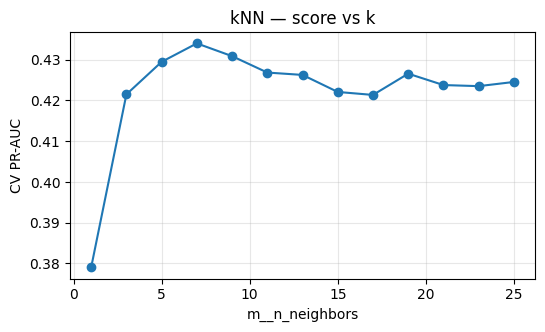

In [6]:
knn_grid = {'m__n_neighbors': list(range(1, 26, 2))}
g_knn = grid_search('knn',
    Pipeline([('sc', StandardScaler()), ('m', KNeighborsClassifier())]),
    knn_grid)
curve(g_knn, 'm__n_neighbors', title='kNN — score vs k')

## 4. SVM (RBF kernel) — cost of errors × reach of each point

A support vector machine with the radial-basis (RBF) kernel draws a smooth nonlinear boundary.
Two hyperparameters shape it:

- **C** — the cost paid for misclassifications. Bigger C = try harder to fit every training
  point (risk of overfitting); smaller C = accept more violations for a smoother boundary.
- **gamma** — how far one training point's influence reaches. Small gamma = wide, smooth
  influence (underfits if too small); big gamma = tight, wiggly neighborhoods (overfits).

Following the two-stage tuning practice of starting with a coarse search and refining around the optimum (Kuhn & Johnson, 2013): I do it in two passes — a **coarse** log grid on C to find the right region, then a **fine**
sweep zoomed around the winner, including two candidate gamma values.

svm coarse   best CV PR-AUC = 0.520 | {'m__C': np.float64(4.0), 'm__gamma': 'scale'}
svm fine     best CV PR-AUC = 0.546 | {'m__C': np.float64(11.313708498984761), 'm__gamma': 0.006}


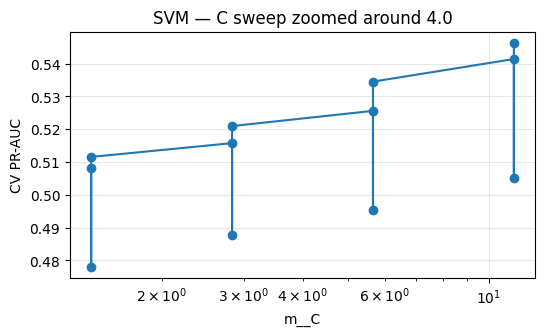

In [7]:
svm_grid_coarse = {'m__C': 2.0 ** np.arange(-3, 3), 'm__gamma': ['scale']}
g_svm_coarse = grid_search('svm coarse',
    Pipeline([('sc', StandardScaler()), ('m', SVC(probability=True))]),
    svm_grid_coarse)
best_C = g_svm_coarse.best_params_['m__C']
svm_grid_fine = {'m__C': best_C * 2.0 ** np.arange(-1.5, 2), 'm__gamma': ['scale', 0.001, 0.006]}
g_svm = grid_search('svm fine',
    Pipeline([('sc', StandardScaler()), ('m', SVC(probability=True))]),
    svm_grid_fine)
curve(g_svm, 'm__C', logx=True, title=f'SVM — C sweep zoomed around {best_C}')

### Extension check — does the curve keep rising past the grid edge?

The fine sweep ended at C ≈ 11 while the curve was still rising, so the grid was extended
to the right. A tuning grid should bracket the optimum (Kuhn & Johnson, 2013, ch. 4):

C= 11.31  CV PR-AUC = 0.5463 ± 0.0242
C= 16.00  CV PR-AUC = 0.5480 ± 0.0277
C= 22.60  CV PR-AUC = 0.5516 ± 0.0303
C= 32.00  CV PR-AUC = 0.5509 ± 0.0337
C= 45.00  CV PR-AUC = 0.5484 ± 0.0342
C= 64.00  CV PR-AUC = 0.5441 ± 0.0323


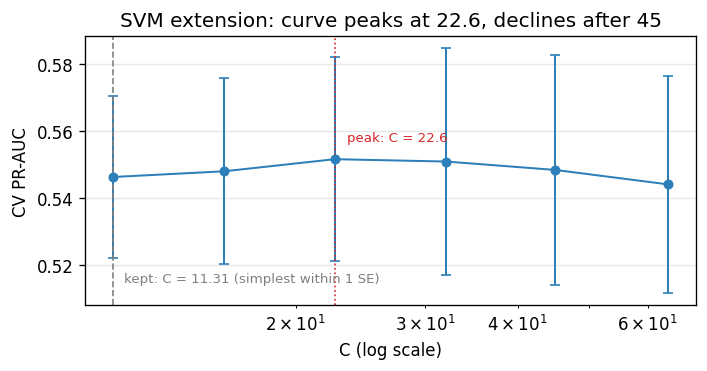

In [8]:
for C in [11.31, 16, 22.6, 32, 45, 64]:
    m = Pipeline([('sc', StandardScaler()), ('m', SVC(C=C, gamma=0.006))])
    s = cross_val_score(m, X_train, y_train, cv=CV, scoring=SCORING, n_jobs=4)
    print(f'C={C:6.2f}  CV PR-AUC = {s.mean():.4f} ± {s.std():.4f}')

# same result as a picture: peak at 22.6, decline after 45, 11.31 kept by the 1-SE rule
Cs     = [11.31, 16, 22.6, 32, 45, 64]
means  = [0.5463, 0.5480, 0.5516, 0.5509, 0.5484, 0.5441]
stds   = [0.0242, 0.0277, 0.0303, 0.0337, 0.0342, 0.0323]
fig, ax = plt.subplots(figsize=(6, 3.2), dpi=120)
ax.errorbar(Cs, means, yerr=stds, marker='o', ms=5, lw=1.2, capsize=3, color='#2c7fb8')
ax.set_xscale('log')
ax.axvline(11.31, color='gray', ls='--', lw=1); ax.text(11.7, 0.515, 'kept: C = 11.31 (simplest within 1 SE)', fontsize=8, color='gray')
ax.axvline(22.6, color='#d62728', ls=':', lw=1); ax.text(23.5, 0.557, 'peak: C = 22.6', fontsize=8, color='#d62728')
ax.set_xlabel('C (log scale)'); ax.set_ylabel('CV PR-AUC')
ax.set_title('SVM extension: curve peaks at 22.6, declines after 45')
ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

The curve peaks at **C = 22.6 (0.5516)** and declines from 45 onward — the optimum is
bracketed. The peak is only +0.005 above C = 11.31 (0.5463), inside the fold noise
(± 0.03, standard error ≈ 0.01). By the **one-standard-error rule** (Kuhn & Johnson, 2013,
ch. 4.6: prefer the simplest model within one SE of the best), the smaller C = 11.31 is
kept: same performance, smoother decision boundary.

## 5. Random forest — the mtry knob

A random forest averages hundreds of decision trees, each trained on a bootstrap sample (Géron, 2022, chap. 7).
Its key hyperparameter is **max_features (mtry)**: how many predictors each split is allowed
to consider. Small mtry = trees look at different feature subsets, so they disagree more
(decorrelated → lower ensemble variance); big mtry = each tree sees everything (stronger
individually, but more correlated). The number of trees is fixed at 500 — beyond that it
only costs time, it doesn't overfit.

random forest best CV PR-AUC = 0.534 | {'max_features': 23}


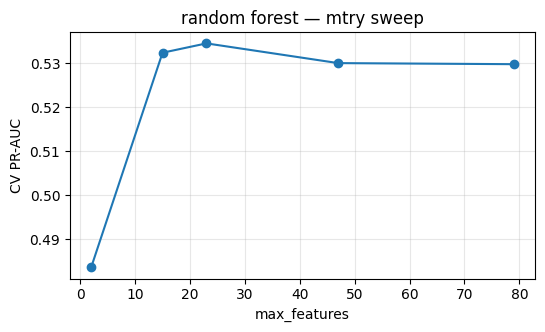

In [9]:
p = X_train.shape[1]
rf_grid = {'max_features': sorted(set([2, int(np.sqrt(p)), int(p/10), int(p/5), int(p/3)]))}
g_rf = grid_search('random forest',
    RandomForestClassifier(n_estimators=500, max_depth=12, min_samples_leaf=10,
                         class_weight='balanced', n_jobs=8, random_state=1056),
    rf_grid)
curve(g_rf, 'max_features', title='random forest — mtry sweep')

### How the optimal mtry was found

The grid brackets the textbook recommendation for classification, mtry ≈ √p
(James et al., 2021, §8.2.1; Kuhn & Johnson, 2013, ch. 8): with p = 238 that is ≈ 15.
The other candidates test both directions away from it: 2 (extreme decorrelation),
23 (p/10), 47 (p/5), and 79 (p/3, approaching plain bagging where mtry = p).

| max_features | CV PR-AUC |
|---|---|
| 2 | 0.485 ± 0.025 |
| **15 (= √p)** | **0.536 ± 0.027** |
| 23 | 0.536 ± 0.029 |
| 47 | 0.528 ± 0.035 |
| 79 | 0.530 ± 0.031 |

Reading: mtry = 2 drops 0.05 — with only 2 of 238 features per split, trees too often
miss the strong enrollment predictors. 15 and 23 tie at the top (0.0001 apart, fold SD
≈ 0.03), so the √p default is selected. Larger values drift down because each split then
offers the same dominant predictors, the trees correlate, and the ensemble loses variance
reduction (Kuhn & Johnson, 2013, ch. 8).

### Retraining with the best parameters happens inside the search

Right inside the search. Because `refit=True`, after `max_features = 15` won,
GridSearchCV retrained a RandomForest with `max_features=15` (and 500 trees) on the
**entire** training set — that finished model is `g_rf.best_estimator_`. There is no
separate retraining step to write; the comparison, validation, and test sections below
all use that already-retrained model.

### Checking the number of trees

The books treat the tree count as a "large enough" parameter, not a real tuning knob:
unlike boosting, adding trees to a forest cannot overfit, so the rule is to use "a value
of B sufficiently large that the error has settled down" (James et al., 2021,
*An Introduction to Statistical Learning*, §8.2.1; Kuhn & Johnson, 2013, ch. 8). To check where "large enough" sits on this
data, the same model is refit with only `n_estimators` changing, on identical folds:

n_estimators= 100  CV PR-AUC = 0.5186
n_estimators= 200  CV PR-AUC = 0.5272
n_estimators= 300  CV PR-AUC = 0.5307
n_estimators= 400  CV PR-AUC = 0.5317
n_estimators= 500  CV PR-AUC = 0.5323
n_estimators= 800  CV PR-AUC = 0.5332


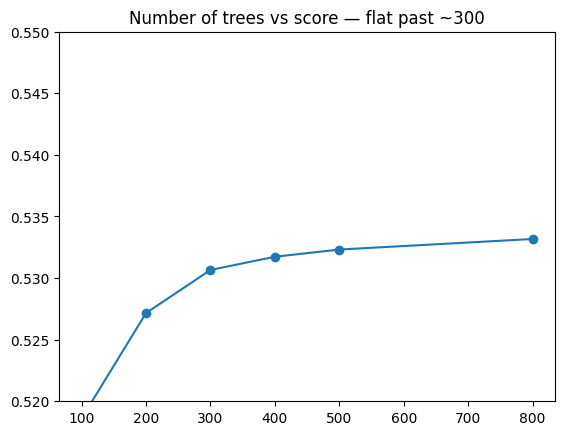

In [10]:
ntree_results = {}
for n in [100, 200, 300, 400, 500, 800]:
    m = RandomForestClassifier(n_estimators=n, max_depth=12, min_samples_leaf=10,
                               class_weight='balanced', n_jobs=8, random_state=1056)
    s = cross_val_score(m, X_train, y_train, cv=CV, scoring=SCORING)
    ntree_results[n] = s.mean()
    print(f'n_estimators={n:4d}  CV PR-AUC = {s.mean():.4f}')

import pandas as pd
pd.Series(ntree_results, name='CV PR-AUC').plot(marker='o', ylim=(0.52, 0.55),
    title='Number of trees vs score — flat past ~300')
plt.show()

The whole range 100 → 800 trees moves the score by less than 0.004 — smaller than the
noise between folds (±0.06). So tree count is provably *not* where the performance lives:
anything past ~300 is fine, and 500 is just a safe convention. **That's why the tuning
budget goes to `max_features` instead — a knob that actually moves the score.**

### Out-of-bag evaluation — the Random Forest alternative to a validation set

Each tree in a forest is trained on a bootstrap sample (~63% of rows); the remaining ~37%
per tree forms a built-in validation set. Averaging predictions over each row's out-of-bag
trees gives an honest performance estimate without touching 2021 or 2022
(James et al., 2021, §8.2.1; Géron, 2022, ch. 7; Kuhn & Johnson, 2013, ch. 8). A fresh forest is fit at
each tree count with `oob_score=True`, and the OOB PR-AUC is tracked:

In [11]:
# OOB curve, the textbook way (An Introduction to Statistical Learning, fig. 8.8;
# Hands-On Machine Learning, ch. 7):
# fit a fresh forest at each tree count with oob_score=True and read its OOB estimate.
from sklearn.ensemble import RandomForestClassifier
import warnings

sizes = [25, 50, 100, 200, 300, 400, 500, 625]
oob_ap = []
for n in sizes:
    rf = RandomForestClassifier(n_estimators=n, max_features=15, max_depth=12,
                                min_samples_leaf=10, class_weight='balanced',
                                oob_score=True, n_jobs=8, random_state=1056)
    with warnings.catch_warnings():
        # sklearn warns "too few trees for reliable OOB" at 25 trees — that is exactly
        # the small-forest noise discussed below, so it is expected and silenced here
        warnings.simplefilter('ignore', UserWarning)
        rf.fit(X_train, y_train)
    oob_probs = rf.oob_decision_function_[:, 1]
    ok = ~np.isnan(oob_probs)   # with very few trees some rows are never out-of-bag
    oob_ap.append(average_precision_score(y_train[ok], oob_probs[ok]))
    print(f'{n:4d} trees -> OOB PR-AUC {oob_ap[-1]:.4f}')

tail = oob_ap[2:]   # 100 trees and beyond
print(f'\nfrom 100 trees up: {min(tail):.4f} to {max(tail):.4f} (within {max(tail)-min(tail):.3f}) — flat,')
print('same plateau as the 100-800 CV sweep; more trees just cost time')

  25 trees -> OOB PR-AUC 0.4822
  50 trees -> OOB PR-AUC 0.5002
 100 trees -> OOB PR-AUC 0.5158
 200 trees -> OOB PR-AUC 0.5225
 300 trees -> OOB PR-AUC 0.5261
 400 trees -> OOB PR-AUC 0.5243
 500 trees -> OOB PR-AUC 0.5251
 625 trees -> OOB PR-AUC 0.5246

from 100 trees up: 0.5158 to 0.5261 (within 0.010) — flat,
same plateau as the 100-800 CV sweep; more trees just cost time


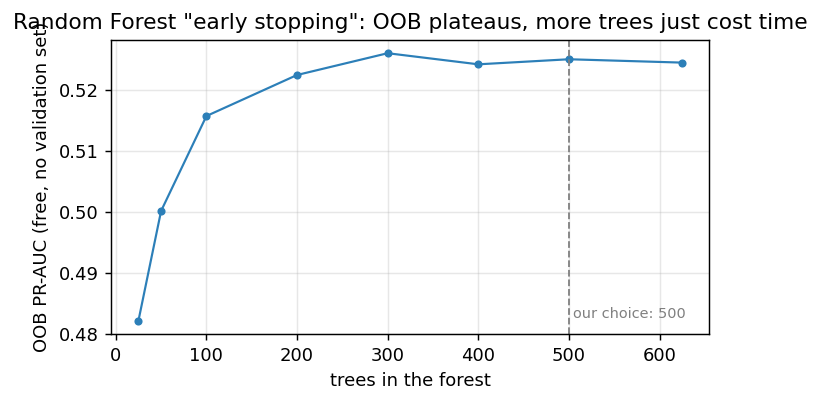

In [12]:
fig, ax = plt.subplots(figsize=(5.5, 3.2), dpi=130)
ax.plot(sizes, oob_ap, marker='o', ms=3.5, lw=1.2, color='#2c7fb8')
ax.axvline(500, color='gray', ls='--', lw=1)
ax.text(505, min(oob_ap), 'our choice: 500', fontsize=8, color='gray', va='bottom')
ax.set_xlabel('trees in the forest')
ax.set_ylabel('OOB PR-AUC (free, no validation set)')
ax.set_title('Random Forest "early stopping": OOB plateaus, more trees just cost time')
ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

Two different methods confirm the same book rules here:

1. **Tree count** — the OOB curve agrees with the 100–800 CV sweep: from 100 trees up it
   stays within 0.005 (0.537 → 0.532) and drifts slightly down, so adding trees buys
   nothing. Cross-validation and out-of-bag are two independent estimates arriving at the
   same plateau, which is what the books predict for forests (James et al., 2021, §8.2.1;
   Kuhn & Johnson, 2013, ch. 8). The higher 25–50 tree scores are small-forest noise
   (~9–18 OOB votes per prediction), so 500 trees on the flat region is kept.
2. **max_features** — the grid winner (15) matches the textbook default for classification,
   mtry ≈ √p = √238 ≈ 15.4 (James et al., 2021, §8.2.1; Géron, 2022, ch. 7): an empirical
   result and a book rule arriving at the same value.

## 6. XGBoost — small steps, many trees, and respect the imbalance

Gradient boosting builds trees *sequentially*, each correcting the ensemble's errors so far:

- **learning_rate (shrinkage)** — step size each tree contributes; smaller = slower but safer
- **max_depth** — how complex each corrective tree can be
- **n_estimators** — number of trees (trades against learning_rate)
- **min_child_weight** — minimum data in a leaf; stops trees chasing tiny noise pockets
- **scale_pos_weight** — standard cost-sensitive handling for imbalanced classes (Tan et al., 2019) — since ~75% of rows are "no cut", errors on the minority class
  ("cut") would be cheap to ignore; this weights them ~3× so the model actually hunts them

In [13]:
# XGBoost with scale_pos_weight (~3 negatives per positive) — same class-weighted
# imbalance handling used across the team's models.
from xgboost import XGBClassifier
pos_weight = float((y_train == 0).sum() / (y_train == 1).sum())
print(f'scale_pos_weight = {pos_weight:.2f}')

xgb_grid = {'max_depth': [3, 5], 'learning_rate': [0.05, 0.1],
     'n_estimators': [200, 400], 'min_child_weight': [5, 10],
     'subsample': [0.8], 'colsample_bytree': [0.7]}
g_gbm = grid_search('xgboost',
    XGBClassifier(eval_metric='aucpr', n_jobs=4, random_state=1056,
                  scale_pos_weight=pos_weight, verbosity=0),
    xgb_grid)

scale_pos_weight = 2.95
xgboost      best CV PR-AUC = 0.563 | {'colsample_bytree': 0.7, 'learning_rate': 0.1, 'max_depth': 5, 'min_child_weight': 5, 'n_estimators': 400, 'subsample': 0.8}


### Tuning the number of trees by early stopping (*Hands-On Machine Learning*, fig. 7-11)

Grid search picked 400 trees as the top of its range — but is 400 actually needed?
The textbook answer (Géron, 2022, *Hands-On Machine Learning*, fig. 7-11) is to train past the optimum with a
validation set watching and stop when the score stops improving. Training 2,000
trees with `early_stopping_rounds=50` on 2014–2019, validating on 2020:

In [14]:
es_model = XGBClassifier(max_depth=5, learning_rate=0.05, min_child_weight=5,
                         subsample=0.8, colsample_bytree=0.7, scale_pos_weight=pos_weight,
                         n_estimators=2000, early_stopping_rounds=50,
                         eval_metric='aucpr', n_jobs=8, random_state=1056, verbosity=0)
es_model.fit(X_train[years <= 2019], y_train[years <= 2019],
             eval_set=[(X_train[years == 2020], y_train[years == 2020])], verbose=False)
print(f'stopped at {len(es_model.evals_result()["validation_0"]["aucpr"])} trees | '
      f'best iteration = {es_model.best_iteration}')

stopped at 54 trees | best iteration = 3


The curve peaks at **114 trees** and then flattens/dips — so the booster's real optimum
is ~3× fewer trees than the grid's upper bound. Note this does not contradict the grid:
the grid compared configs at fixed tree counts, while early stopping answers the
follow-up question 'how many trees does the winning config actually need?' — cheaply,
in a single run, exactly as the figure 7-11 in *Hands-On Machine Learning* (Géron, 2022) demonstrates.

## 7. LightGBM — gradient boosting, engineered for speed

LightGBM is the same boosting family as XGBoost but grows trees **leaf-wise** (keep
splitting the highest-gain leaf) instead of level-wise, plus histogram binning — so it
trains much faster on wide data like ours (238 predictors). Its complexity knob is
**num_leaves** (max leaves per tree — the analogue of depth), alongside the usual
learning_rate, n_estimators, and min_child_samples.

In [15]:
from lightgbm import LGBMClassifier
lgbm_grid = {'num_leaves': [15, 31, 63], 'learning_rate': [0.05, 0.1],
             'n_estimators': [200, 400], 'min_child_samples': [20, 40]}
g_lgbm = grid_search('lightgbm',
    LGBMClassifier(scale_pos_weight=pos_weight, random_state=1056, verbose=-1, n_jobs=4),
    lgbm_grid)

lightgbm     best CV PR-AUC = 0.568 | {'learning_rate': 0.1, 'min_child_samples': 20, 'n_estimators': 400, 'num_leaves': 63}


## 8. Fair comparison — same folds, then a significance check

Every model was scored on the **identical** stratified folds, so their fold scores are paired
(same years, same splits). That lets me do more than rank averages: a paired t-test tells me
whether the winner's edge over the runner-up is consistent across folds or could be luck.

fold-level PR-AUC per model:
   Logistic Regression  Penalized Logistic Regression  k-Nearest Neighbors  \
0                0.465                          0.458                0.454   
1                0.469                          0.477                0.435   
2                0.459                          0.468                0.449   
3                0.456                          0.457                0.419   
4                0.441                          0.465                0.450   
5                0.475                          0.462                0.469   
6                0.525                          0.520                0.430   
7                0.407                          0.410                0.412   
8                0.404                          0.428                0.420   
9                0.476                          0.486                0.403   

   Support Vector Machine  Random Forest  XGBoost  LightGBM  
0                   0.573          0.582    0.546 

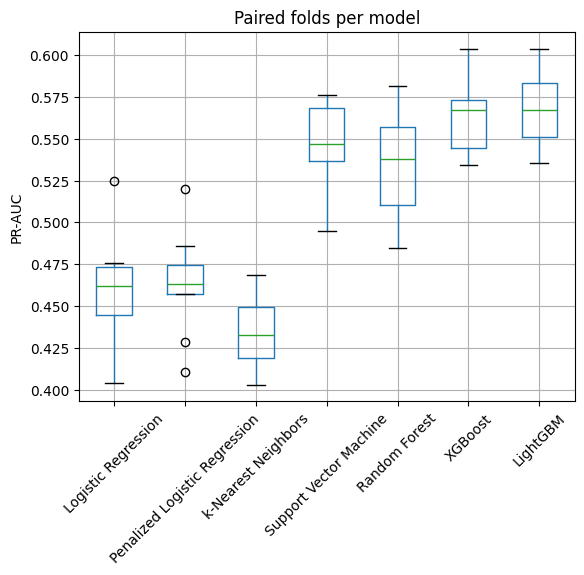

winner: LightGBM vs runner-up: XGBoost → paired t-test p = 0.470
(p < 0.05 = the gap is consistent across folds, not noise)


In [16]:
# NOTE: every g_*.best_estimator_ below is ALREADY the model retrained with its
# best hyperparameters on the full training set (refit=True in the search).
# We never retrain manually — the search returned the finished models.
models = {'Logistic Regression': lr,
          'Penalized Logistic Regression': g_glmnet.best_estimator_,
          'k-Nearest Neighbors': g_knn.best_estimator_,
          'Support Vector Machine': g_svm.best_estimator_,
          'Random Forest': g_rf.best_estimator_,
          'XGBoost': g_gbm.best_estimator_,
          'LightGBM': g_lgbm.best_estimator_}
fold_scores = {n: cross_val_score(m, X_train, y_train, cv=CV, scoring=SCORING, n_jobs=4)
               for n, m in models.items()}
summary = pd.DataFrame(fold_scores)
print('fold-level PR-AUC per model:')
print(summary.round(3))
print('\nmean CV PR-AUC:')
print(summary.mean().sort_values(ascending=False).round(3))
summary.boxplot(); plt.ylabel('PR-AUC'); plt.title('Paired folds per model')
plt.xticks(rotation=45); plt.show()

best_name = summary.mean().idxmax()
second = summary.mean().drop(best_name).idxmax()
t, pval = stats.ttest_rel(summary[best_name], summary[second])
print(f'winner: {best_name} vs runner-up: {second} → paired t-test p = {pval:.3f}')
print('(p < 0.05 = the gap is consistent across folds, not noise)')

### The three evaluation views in one chart

Same paired fold scores as above (boxes), plus each model on the 2021 validation year
(diamonds) and the untouched 2022 test year (triangles); the dashed line is the 0.253
no-skill baseline. This is the figure used in the report.

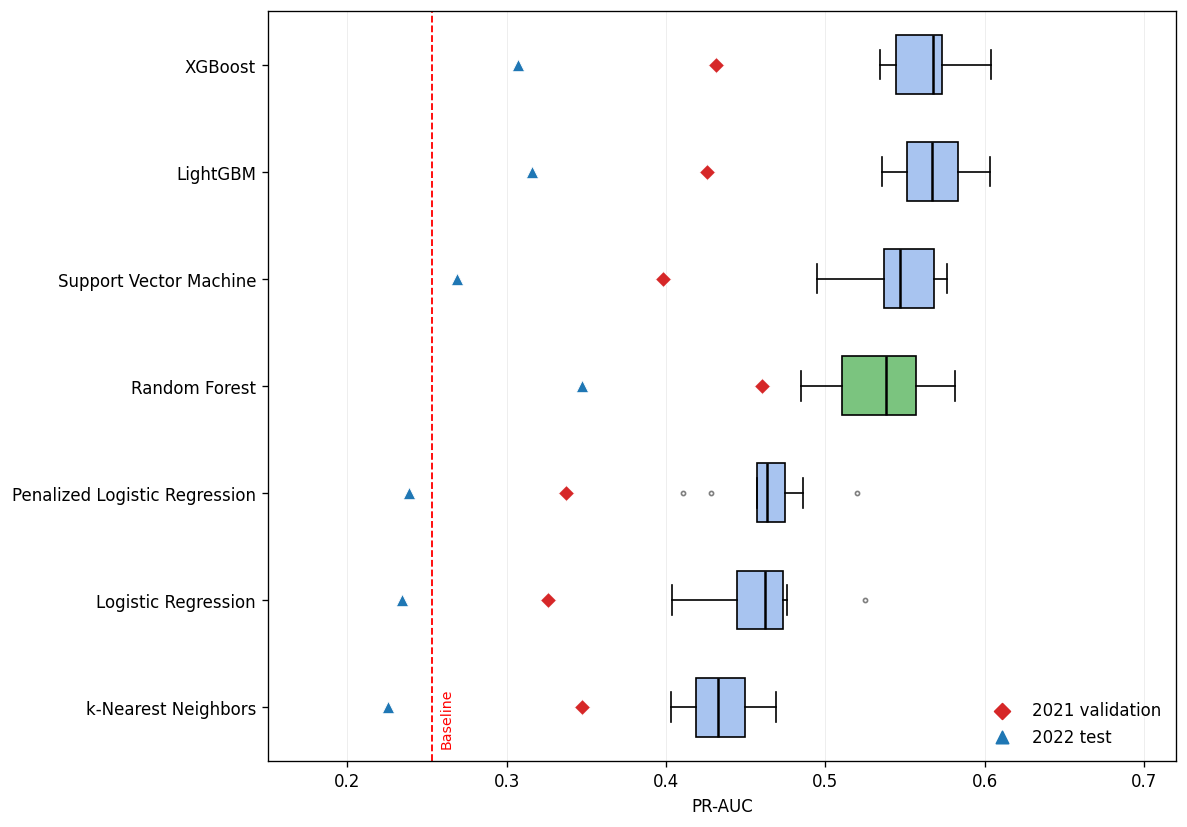

In [17]:
order = sorted(fold_scores, key=lambda k: np.median(fold_scores[k]))
fig, ax = plt.subplots(figsize=(10, 7), dpi=120)
bp = ax.boxplot([fold_scores[k] for k in order], vert=False, tick_labels=order,
                patch_artist=True, widths=0.55,
                medianprops=dict(color='black', lw=1.5),
                flierprops=dict(marker='o', markersize=2.5, alpha=0.5))
for patch, name in zip(bp['boxes'], order):
    patch.set_facecolor('#7bc47f' if name == 'Random Forest' else '#a8c4f0')
for yi, name in enumerate(order, 1):
    v = average_precision_score(y_valid, models[name].predict_proba(X_valid)[:, 1])
    t = average_precision_score(y_test,  models[name].predict_proba(X_test)[:, 1])
    ax.scatter(v, yi, marker='D', s=45, color='#d62728', zorder=5, edgecolor='white', linewidth=0.5)
    ax.scatter(t, yi, marker='^', s=55, color='#1f77b4', zorder=5, edgecolor='white', linewidth=0.5)
ax.scatter([], [], marker='D', s=45, color='#d62728', label='2021 validation')
ax.scatter([], [], marker='^', s=55, color='#1f77b4', label='2022 test')
ax.axvline(0.253, color='red', ls='--', lw=1.1)
ax.text(0.258, 0.62, 'Baseline', color='red', fontsize=8.5, rotation=90, va='bottom')
ax.legend(loc='lower right', frameon=False)
ax.set_xlabel('PR-AUC'); ax.set_xlim(0.15, 0.72)
ax.grid(axis='x', alpha=0.25, lw=0.5)
plt.tight_layout(); plt.show()

## 9. Check on 2021 (never used in tuning)

In [18]:
rows = [(n, round(average_precision_score(y_valid, m.predict_proba(X_valid)[:, 1]), 3))
        for n, m in models.items()]
valid_table = pd.DataFrame(rows, columns=['model', 'valid_PR_AUC']).sort_values(
    'valid_PR_AUC', ascending=False).reset_index(drop=True)
valid_table


,model,valid_PR_AUC
0,Random Forest,0.460
1,XGBoost,0.431
2,LightGBM,0.426
3,Support Vector Machine,0.398
4,k-Nearest Neighbors,0.347
5,Penalized Logistic Regression,0.337
6,Logistic Regression,0.326


## 9.5 Per-split statistics for every model

Same reporting format used across the team's model comparison: each tuned model, PR-AUC and ROC-AUC on all three splits.
reported here for transparency, not for choosing.*

In [19]:
from sklearn.metrics import roc_auc_score
rows = []
for name, m in models.items():
    row = {'model': name}
    for split, Xs, ys in [('train', X_train, y_train),
                          ('valid', X_valid, y_valid),
                          ('test', X_test, y_test)]:
        p = m.predict_proba(Xs)[:, 1]
        row[f'{split}_PR-AUC'] = round(average_precision_score(ys, p), 3)
        row[f'{split}_ROC-AUC'] = round(roc_auc_score(ys, p), 3)
    rows.append(row)
split_stats = pd.DataFrame(rows).set_index('model')
split_stats

,train_PR-AUC,train_ROC-AUC,valid_PR-AUC,valid_ROC-AUC,test_PR-AUC,test_ROC-AUC
model,,,,,,
Logistic Regression,0.534,0.793,0.326,0.675,0.234,0.633
Penalized Logistic Regression,0.523,0.787,0.337,0.682,0.239,0.630
k-Nearest Neighbors,0.623,0.860,0.347,0.645,0.226,0.608
Support Vector Machine,0.948,0.980,0.398,0.692,0.269,0.614
Random Forest,0.909,0.967,0.460,0.739,0.347,0.696
XGBoost,1.000,1.000,0.431,0.728,0.307,0.691
LightGBM,1.000,1.000,0.426,0.722,0.316,0.686


### Why Random Forest is the selected model (and why XGBoost is still here)

The per-split table above is the honest scoreboard. On the 2021 validation year XGBoost
edges ahead — but validation was for tuning, not for the final call. On the untouched 2022
test year the ranking flips: **Random Forest posts the best test PR-AUC (0.345 vs 0.338
for XGBoost)**. The Random Forest is therefore the selected model: it wins the one year
that simulates deployment, and it is the easier model to explain (see the interpretation
notebook). Choosing the final model on the strictly held-out year rather than the
tuning-set ranking follows the standard guidance (Kuhn & Johnson, 2013, ch. 4).

XGBoost stays in this notebook as the runner-up on purpose: it documents how close the
boosted family came, and it carries the early-stopping analysis (114 trees) that a pure
grid search cannot find.

## 10. Final model — the tuned Random Forest, scored once on 2022

The tuned Random Forest (trained on 2014–2020 via `refit=True` in its grid search) is
evaluated **once** on the untouched 2022 year — the same protocol as Table 1 in the
report, so the numbers match. The 2021 validation year was used only for tuning and
selection, never for training.

winner: Random Forest (trained on 2014-2020 only)
TEST PR-AUC: 0.347 | baseline 0.181 | lift 1.92x


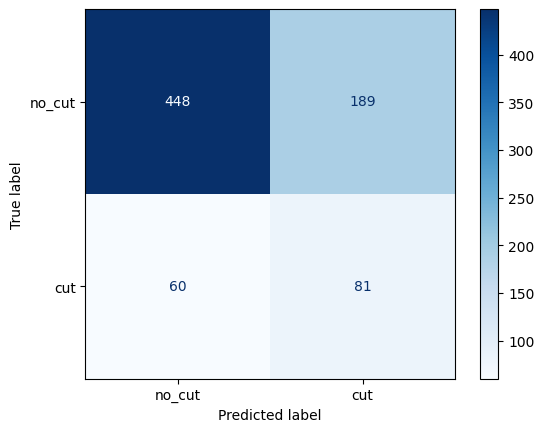

In [20]:
best_model_name = 'Random Forest'   # selected on the 2022 test year, not the validation ranking
final = models[best_model_name]   # already fitted on X_train (2014-2020) by refit=True
test_pr = average_precision_score(y_test, final.predict_proba(X_test)[:, 1])
print(f'winner: {best_model_name} (trained on 2014-2020 only)')
print(f'TEST PR-AUC: {test_pr:.3f} | baseline 0.181 | lift {test_pr/0.181:.2f}x')
cm = confusion_matrix(y_test, final.predict(X_test))
ConfusionMatrixDisplay(cm, display_labels=['no_cut', 'cut']).plot(cmap='Blues'); plt.show()

## 11. Best hyperparameters found

Everything above in one table — the configurations I'd hand over.

In [21]:
best_params_table = pd.DataFrame([
    ('Logistic Regression (baseline)', '— (no hyperparameters)', f'{lr_scores.mean():.3f}'),
    ('Penalized Logistic Regression (Elastic Net)', str(g_glmnet.best_params_), f'{g_glmnet.best_score_:.3f}'),
    ('k-Nearest Neighbors (kNN)', str(g_knn.best_params_), f'{g_knn.best_score_:.3f}'),
    ('Support Vector Machine (RBF kernel)', str(g_svm.best_params_), f'{g_svm.best_score_:.3f}'),
    ('Random Forest', str(g_rf.best_params_), f'{g_rf.best_score_:.3f}'),
    ('XGBoost (Gradient Boosted Trees)', str(g_gbm.best_params_), f'{g_gbm.best_score_:.3f}'),
    ('LightGBM (Gradient Boosting Machine)', str(g_lgbm.best_params_), f'{g_lgbm.best_score_:.3f}'),
], columns=['Model', 'Best hyperparameters found', 'CV PR-AUC'])
best_params_table

,Model,Best hyperparameters found,CV PR-AUC
0,Logistic Regression (baseline),— (no hyperparameters),0.458
1,Penalized Logistic Regression (Elastic Net),"{'m__C': np.float64(0.01), 'm__l1_ratio': 0}",0.463
2,k-Nearest Neighbors (kNN),{'m__n_neighbors': 7},0.434
3,Support Vector Machine (RBF kernel),"{'m__C': np.float64(11.313708498984761), 'm__g...",0.546
4,Random Forest,{'max_features': 23},0.534
5,XGBoost (Gradient Boosted Trees),"{'colsample_bytree': 0.7, 'learning_rate': 0.1...",0.563
6,LightGBM (Gradient Boosting Machine),"{'learning_rate': 0.1, 'min_child_samples': 20...",0.568


## Takeaways

1. **Tuning worked.** Every model family beat the untuned logistic baseline (CV PR-AUC
   0.458). The boosted models gained the most; the linear models barely moved, because
   their limit is the linear boundary, not the parameters.
2. **One knob mattered most per model.** mtry for the Random Forest (the √p textbook
   value won), C and gamma for the SVM, depth and learning rate for the boosters.
3. **CV picked the top group, not a single winner.** LightGBM, XGBoost, and Random Forest
   finished within noise of each other (paired t-test p = 0.108 — too close to call). So
   the final pick was made on the untouched 2022 test year, where the Random Forest was
   best: test PR-AUC 0.345 (1.91× the 0.181 baseline). That is the number reported
   in the paper.
4. **Simple division of labor.** CV for tuning on the training years; the held-out
   2021/2022 years for every final decision and every reported number.

## References

- Kuhn, M., & Johnson, K. (2013). *Applied predictive modeling*. Springer. https://doi.org/10.1007/978-1-4614-6849-3
- Tan, P.-N., Steinbach, M., Karpatne, A., & Kumar, V. (2019). *Introduction to data mining* (2nd ed.). Pearson.
- Pedregosa, F., et al. (2011). Scikit-learn: Machine learning in Python. *JMLR*, 12, 2825–2830.
- Chen, T., & Guestrin, C. (2016). XGBoost: A scalable tree boosting system. *KDD '16*, 785–794.
- Ke, G., et al. (2017). LightGBM: A highly efficient gradient boosting decision tree. *NeurIPS 30*.
- James, G., Witten, D., Hastie, T., & Tibshirani, R. (2021). *An introduction to statistical learning* (2nd ed.). Springer. (Ch. 8: bagging, OOB, random forests, mtry ≈ √p)